# 3. starfold — refinement toolkit

Notebook 1 produced a clustering; notebook 2 confirmed it's real.
This notebook shows four tools for *working with* the result:

* **chunked silhouette** — `sklearn`'s silhouette score without the
  `N × N` distance matrix, so it scales to 10⁵+ samples.
* **merge recommender** — pairs of clusters that are plausibly one,
  combining HDBSCAN's density-level cohesion with an embedding-space
  overlap test.
* **sub-cluster refit** — the paper's two-run workflow, one line.
* **uncertainty propagation & uncertainty-aware fit** — when the
  features carry 1σ error bars.

In [1]:
from __future__ import annotations

import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent / "examples"))
from torus_chain import make_torus_chain  # noqa: E402

import starfold as sf  # noqa: E402

FIGURE_DIR = Path("figures") / "tutorial_03_advanced"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print(f"starfold {sf.__version__}")

starfold 0.0.1


## 3.0 Set-up: fit the pipeline

3 200-point torus chain. No noise baseline (notebook 2 covers it).
`engine="cpu"` is pinned so the fitted UMAP + HDBSCAN models stay
in memory for the uncertainty demos further down (cuML does not yet
expose the transform + `approximate_predict` path the propagator
needs).

In [2]:
X, y_true = make_torus_chain(
    n_links=8,
    points_per_link=400,
    big_radius=4.0,
    major_even=2.0,
    major_odd=2.5,
    minor_radius=0.15,
    solid=True,
    noise_std=0.02,
    random_state=0,
)

pipeline = sf.UnsupervisedPipeline(
    umap_kwargs={"n_epochs": 400, "n_neighbors": 25, "min_dist": 0.0},
    hdbscan_optuna_trials=20,
    mcs_range=(80, 500),
    ms_range=(5, 25),
    engine="cpu",
    skip_noise_baseline=True,
    random_state=0,
)
t0 = time.perf_counter()
result = pipeline.fit(X)
print(f"pipeline.fit took {time.perf_counter() - t0:.1f}s "
      f"→ {result.n_clusters} clusters")

pipeline.fit took 33.9s → 9 clusters


/tmp/ipykernel_17181/1145428053.py:23: UserWarning: Optuna best was reached 16 trials before the end of the 20-trial budget; consider halving n_trials on similar runs to save compute.
  result = pipeline.fit(X)


## 3.1 Chunked silhouette

The silhouette coefficient
$s(i) = \bigl(b(i) - a(i)\bigr) / \max\bigl(a(i), b(i)\bigr)$
measures how much closer each sample sits to its own cluster than to
the nearest foreign one. The textbook implementation builds an
$N \times N$ distance matrix — 80 GB at $N = 10^5$ — and blows up
before the score arrives.

`chunked_silhouette` streams the distance rows in blocks of
`chunk_size` samples. The result matches
`sklearn.metrics.silhouette_samples` at `atol = 1e-10`.

overall silhouette : 0.6878
outliers skipped   : 0


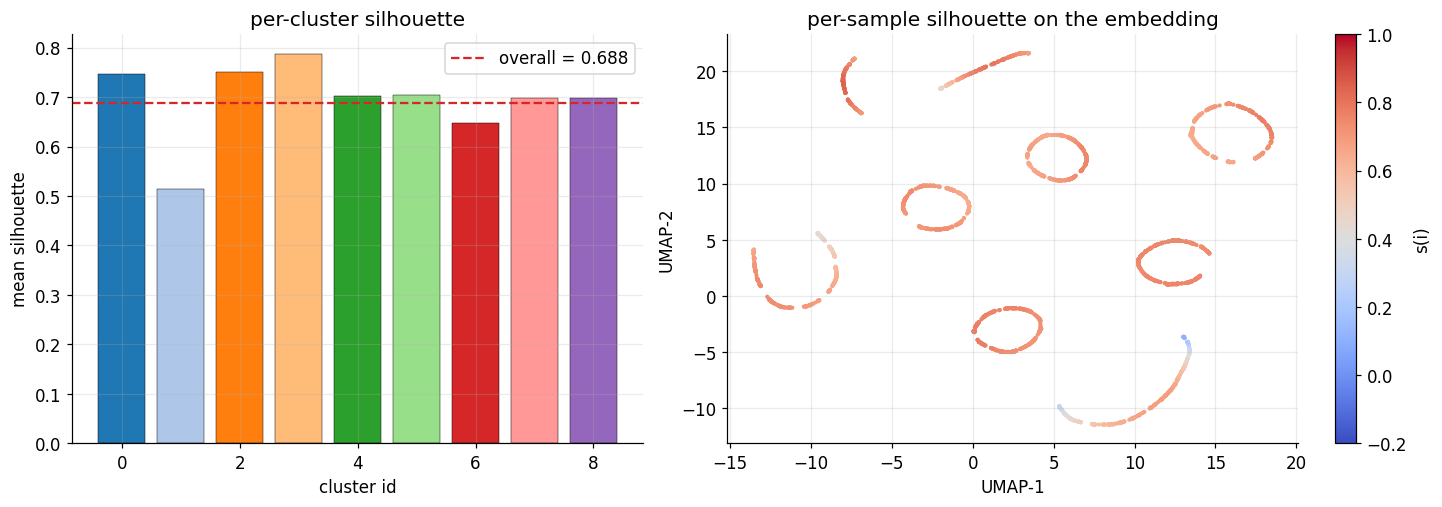

In [3]:
sil = result.silhouette(chunk_size=256)
print(f"overall silhouette : {sil.overall:.4f}")
print(f"outliers skipped   : {sil.n_outliers}")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.5), constrained_layout=True)
cmap = plt.get_cmap("tab20")
colours = [cmap(i % 20) for i in range(len(sil.per_cluster))]
axes[0].bar(np.arange(len(sil.per_cluster)), sil.per_cluster,
            color=colours, edgecolor="black", linewidth=0.3)
axes[0].axhline(sil.overall, color="tab:red", linestyle="--",
                label=f"overall = {sil.overall:.3f}")
axes[0].axhline(0.0, color="black", linewidth=0.6)
axes[0].set_xlabel("cluster id")
axes[0].set_ylabel("mean silhouette")
axes[0].set_title("per-cluster silhouette")
axes[0].legend()

keep = result.labels >= 0
sc = axes[1].scatter(
    result.embedding[keep, 0], result.embedding[keep, 1],
    c=sil.per_sample[keep], cmap="coolwarm", vmin=-0.2, vmax=1.0, s=3,
)
if (~keep).any():
    axes[1].scatter(
        result.embedding[~keep, 0], result.embedding[~keep, 1],
        c="lightgrey", s=3, label="outlier",
    )
plt.colorbar(sc, ax=axes[1], label="s(i)")
axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
axes[1].set_title("per-sample silhouette on the embedding")
fig.savefig(FIGURE_DIR / "01_silhouette.png")
plt.show()

## 3.2 Cluster-merge recommender

Two clusters are *plausibly one* when the density tree splits them
shallowly **and** they sit on top of each other in the embedding.
`suggest_merges` combines both:

* **cohesion ratio** = $\lambda_\text{merge} / \max(\lambda_i, \lambda_j)$
  from the condensed tree. Close to 1 means the split is shallow.
* **gap ratio** = $\|c_i - c_j\| / \max(r_i, r_j)$ in the
  embedding. Below 1 means the clusters overlap.

A pair is `recommended` only when both agree.

36 pairs considered, 0 recommended for merge

  i   j   cohesion   gap/RMS lambda_merge  rec
  1   2      1.000     3.148        0.212    
  3   4      1.000     4.176        0.188    
  7   8      1.000     4.328        0.205    
  6   7      0.879     3.675        0.180    
  6   8      0.879     6.664        0.180    
  0   1      0.838     2.616        0.178    
  0   2      0.838     5.755        0.178    
  5   6      0.832    10.302        0.150    
  0   5      0.742     9.033        0.132    
  0   6      0.734     4.814        0.132    


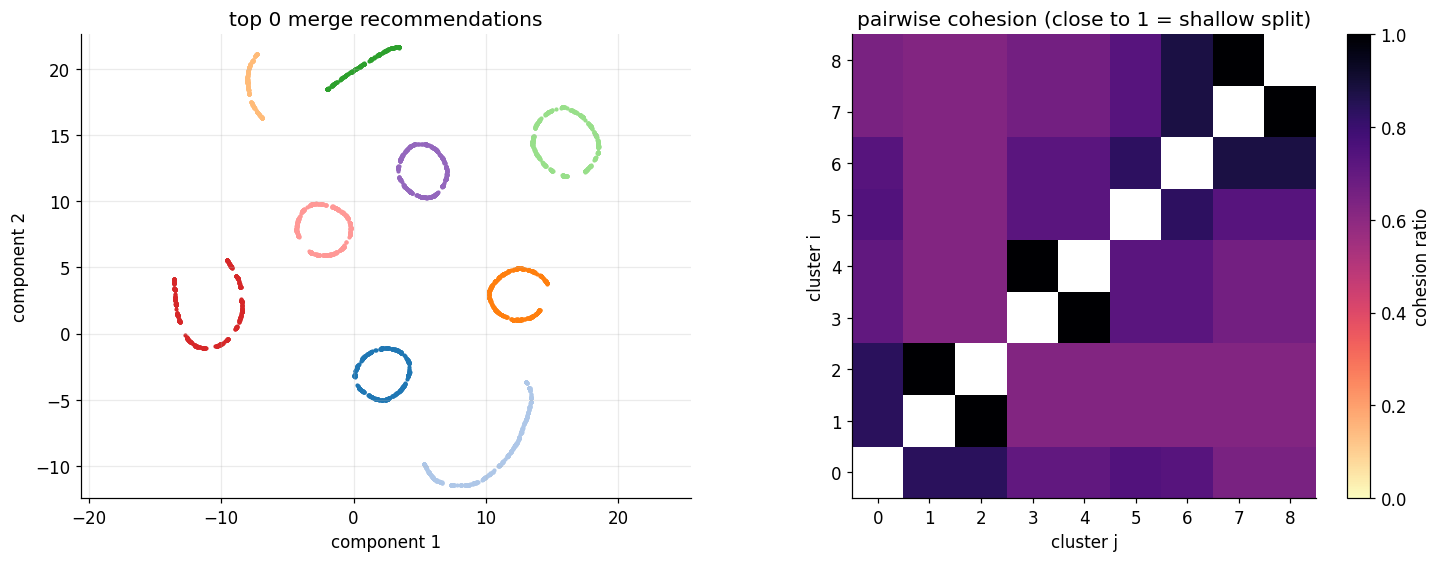

In [4]:
suggestions = result.suggest_merges(sort_by="cohesion_ratio")
recommended = [s for s in suggestions if s.recommended]
print(f"{len(suggestions)} pairs considered, "
      f"{len(recommended)} recommended for merge")
print()
print(f"{'i':>3} {'j':>3}  {'cohesion':>9} {'gap/RMS':>9} "
      f"{'lambda_merge':>12}  rec")
for s in suggestions[:10]:
    flag = "**" if s.recommended else "  "
    print(f"{s.cluster_i:>3d} {s.cluster_j:>3d}  "
          f"{s.cohesion_ratio:>9.3f} {s.gap_ratio:>9.3f} "
          f"{s.merge_lambda:>12.3f}  {flag}")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), constrained_layout=True)
sf.plot_embedding(result.embedding, result.labels, ax=axes[0],
                  point_size=3.0, cmap="tab20")
top3 = recommended[:3]
for n_, s in enumerate(top3):
    ci = result.embedding[result.labels == s.cluster_i].mean(axis=0)
    cj = result.embedding[result.labels == s.cluster_j].mean(axis=0)
    axes[0].plot([ci[0], cj[0]], [ci[1], cj[1]], "--",
                 color=plt.get_cmap("autumn")(
                     n_ / max(1, len(top3) - 1) or 0.0),
                 linewidth=2.0,
                 label=f"pair {s.cluster_i}-{s.cluster_j}  "
                       f"(coh={s.cohesion_ratio:.2f}, gap={s.gap_ratio:.2f})")
if top3:
    axes[0].legend(fontsize=8, framealpha=0.9)
axes[0].set_title(f"top {len(top3)} merge recommendations")

n = result.n_clusters
heat = np.full((n, n), np.nan)
for s in suggestions:
    heat[s.cluster_i, s.cluster_j] = s.cohesion_ratio
    heat[s.cluster_j, s.cluster_i] = s.cohesion_ratio
im = axes[1].imshow(heat, cmap="magma_r", vmin=0.0, vmax=1.0, origin="lower")
plt.colorbar(im, ax=axes[1], label="cohesion ratio")
axes[1].set_xticks(range(n)); axes[1].set_yticks(range(n))
axes[1].set_xlabel("cluster j"); axes[1].set_ylabel("cluster i")
axes[1].set_title("pairwise cohesion (close to 1 = shallow split)")
axes[1].grid(False)
fig.savefig(FIGURE_DIR / "02_merge_recommendations.png")
plt.show()

## 3.3 Sub-cluster refit — the paper's two-run workflow

The paper's second-run idea (first cluster the full sample, then
re-run the pipeline inside each top-level component) is a one-liner:
`result.refit_subcluster(X, cluster_id=k)` re-fits the scaler, UMAP,
Optuna search, and trustworthiness on the subset of `X` that fell
into cluster `k`. Handy for peeling apart a cluster that looks like
it might contain sub-structure.

re-fitting inside cluster 0 (n = 400 points)


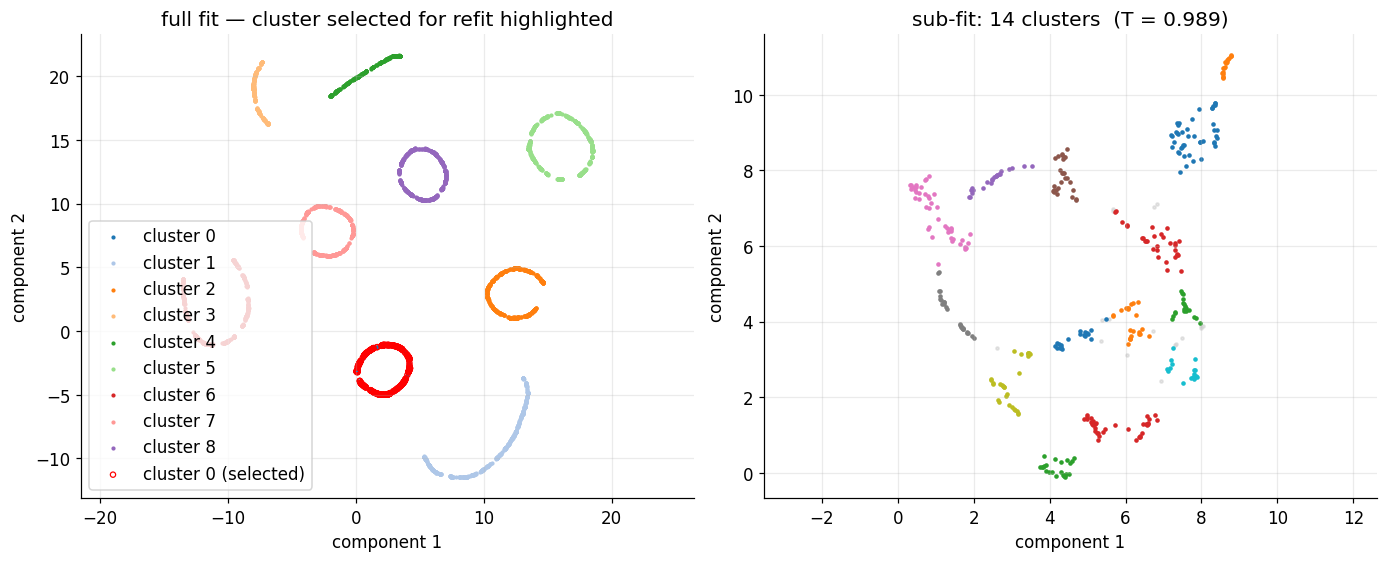


starfold pipeline result
--------------------------------
n_samples        400
n_clusters       14
n_outliers       17  (4.2%)
trustworthiness  0.9892
continuity       0.9670
objective        persistence_sum
best_params      {'min_cluster_size': 17, 'min_samples': 6, 'cluster_selection_method': 'leaf', 'cluster_selection_epsilon': 0.30149406536882317, 'alpha': 0.7113254290194835}
persistence_sum  4.1071
persistence_med  0.3060
DBCV (MST proxy) 0.1874
persistence      [0.365 0.656 0.496 0.433 0.366 0.48  0.381 0.121 0.247 0.019 0.173 0.088
 0.129 0.153]


In [5]:
biggest = int(np.argmax(np.bincount(result.labels[result.labels >= 0])))
n_biggest = int(np.sum(result.labels == biggest))
print(f"re-fitting inside cluster {biggest} (n = {n_biggest} points)")

sub_result = result.refit_subcluster(
    X, biggest,
    overrides={
        "hdbscan_optuna_trials": 15,
        "umap_kwargs": {"n_epochs": 300, "n_neighbors": 20, "min_dist": 0.0},
        "mcs_range": (15, 150),
        "ms_range": (3, 15),
        "skip_noise_baseline": True,
    },
)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), constrained_layout=True)
sf.plot_embedding(result.embedding, result.labels, ax=axes[0],
                  point_size=3.0, cmap="tab20")
mask = result.labels == biggest
axes[0].scatter(result.embedding[mask, 0], result.embedding[mask, 1],
                facecolors="none", edgecolors="red", s=12, linewidths=0.8,
                label=f"cluster {biggest} (selected)")
axes[0].legend()
axes[0].set_title("full fit — cluster selected for refit highlighted")

sf.plot_embedding(sub_result.embedding, sub_result.labels, ax=axes[1],
                  point_size=4.0, cmap="tab10")
axes[1].set_title(
    f"sub-fit: {sub_result.n_clusters} clusters  "
    f"(T = {sub_result.trustworthiness:.3f})"
)
fig.savefig(FIGURE_DIR / "03_subcluster_refit.png")
plt.show()
print()
print(sub_result.summary())

## 3.4 Input-uncertainty propagation

Real features carry error bars. `result.propagate_uncertainty` asks
*given the fitted clustering, how noisy would each sample's
assignment be under Gaussian perturbations of the input?* It does
**not** refit; it projects perturbed copies through the same scaler,
UMAP, and HDBSCAN `approximate_predict`.

`sigma` accepts a scalar, a per-feature vector, or a
per-sample-per-feature matrix — here an isotropic 0.05
(about a third of the tube radius).

median instability : 0.000
max instability    : 0.050
confident at 0.8   : 3200 / 3200


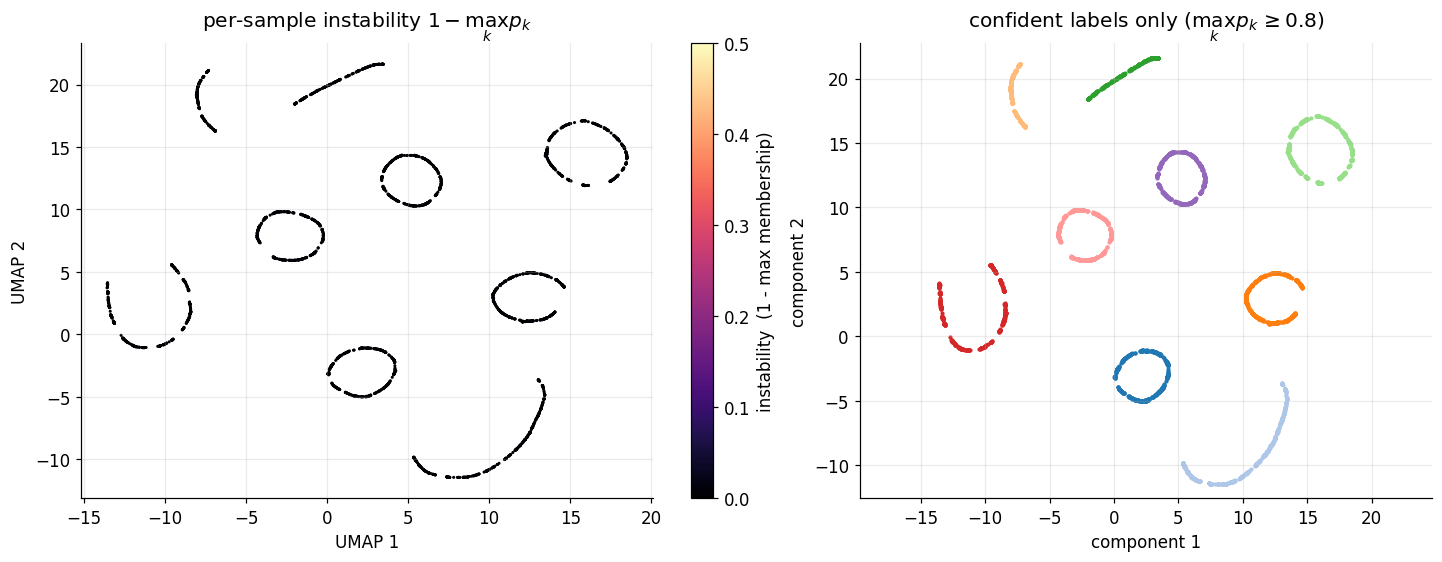

In [6]:
propagation = result.propagate_uncertainty(
    X, sigma=0.05, n_draws=20, random_state=0,
)
print(f"median instability : {float(np.median(propagation.instability)):.3f}")
print(f"max instability    : {float(np.max(propagation.instability)):.3f}")
print(f"confident at 0.8   : "
      f"{int(np.sum(propagation.instability < 0.2))} / {len(X)}")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), constrained_layout=True)
sf.plot_uncertainty_map(result.embedding, propagation, ax=axes[0], s=4.0)
axes[0].set_title(r"per-sample instability $1 - \max_k p_k$")

conf = propagation.confident_labels(threshold=0.8)
sf.plot_embedding(result.embedding, conf, ax=axes[1], point_size=3.0,
                  cmap="tab20")
axes[1].set_title(r"confident labels only ($\max_k p_k \geq 0.8$)")
fig.savefig(FIGURE_DIR / "04_uncertainty_propagation.png")
plt.show()

## 3.5 Uncertainty-aware fit

`propagate_uncertainty` freezes a clean fit and asks whether each
sample's assignment survives jitter. Sometimes that's the wrong
question: maybe the errors are large enough that UMAP and HDBSCAN
should *see* them during fitting.

`pipeline.fit_with_uncertainty(X, sigma, n_replicas)` stacks `X` with
`n_replicas` Gaussian-perturbed copies and fits the whole pipeline
on the augmented matrix. UMAP and HDBSCAN adapt their manifold and
density estimates to the error cloud rather than ignoring it.

/home/aneitzel/projects/starfold/src/starfold/pipeline.py:1022: UserWarning: Optuna best was reached 16 trials before the end of the 20-trial budget; consider halving n_trials on similar runs to save compute.
  augmented_result = self.fit(x_aug)


augmented n_samples : 9600
original n_samples  : 3200
aware n_clusters    : 41
median instability  : 0.000


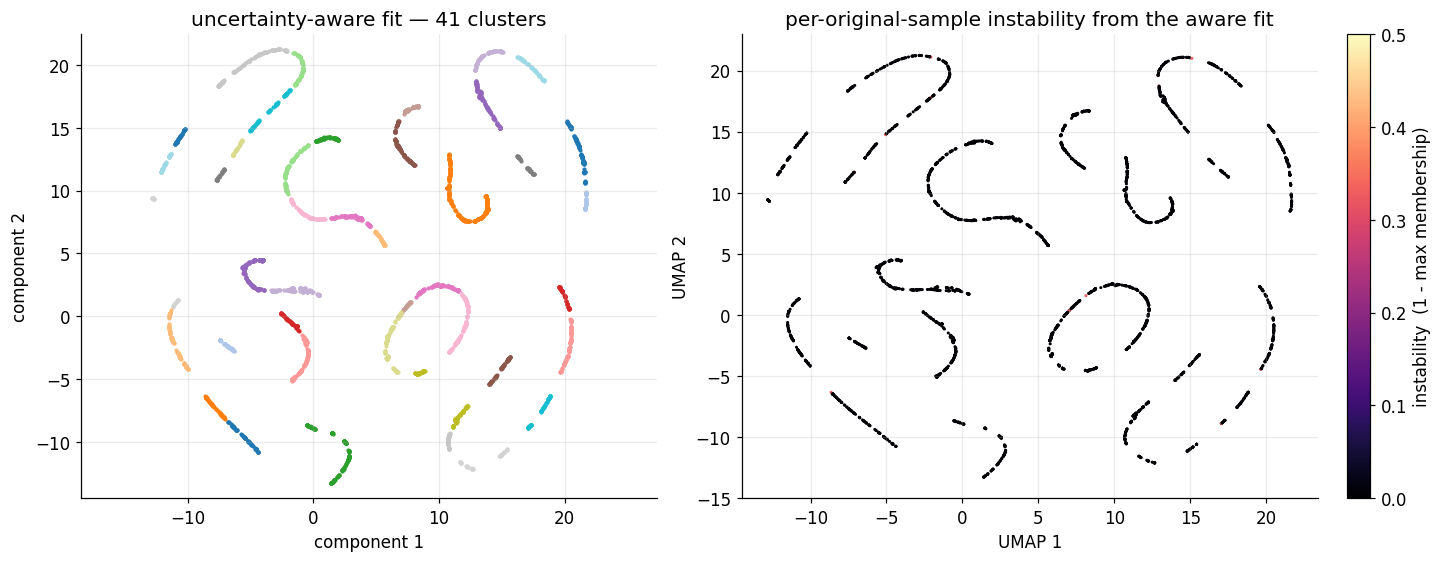

In [7]:
aware = pipeline.fit_with_uncertainty(X, sigma=0.05, n_replicas=2)
print(f"augmented n_samples : {aware.augmented_result.embedding.shape[0]}")
print(f"original n_samples  : {len(X)}")
print(f"aware n_clusters    : {aware.augmented_result.n_clusters}")
print(f"median instability  : "
      f"{float(np.median(aware.propagation.instability)):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.0), constrained_layout=True)
sf.plot_embedding(
    aware.augmented_result.embedding[:len(X)],
    aware.augmented_result.labels[:len(X)],
    ax=axes[0], point_size=3.0, cmap="tab20",
)
axes[0].set_title(
    f"uncertainty-aware fit — {aware.augmented_result.n_clusters} clusters"
)

sf.plot_uncertainty_map(
    aware.augmented_result.embedding[:len(X)],
    aware.propagation,
    ax=axes[1], s=4.0,
)
axes[1].set_title("per-original-sample instability from the aware fit")
fig.savefig(FIGURE_DIR / "05_uncertainty_aware_fit.png")
plt.show()

## 3.6 Takeaways

* `chunked_silhouette` scales where `sklearn`'s default blows up.
* `suggest_merges` combines density and geometric evidence; only
  flag pairs both agree on.
* `refit_subcluster` is the paper's two-run workflow, one line.
* `propagate_uncertainty` is cheap (no refit); `fit_with_uncertainty`
  is the more honest alternative when errors are large.

Next up: **[4. Astronomy case study](tutorial_04_astronomy.ipynb)** —
the same pipeline on real data.